# 4 state dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def state_count(data):
    total=pd.DataFrame(data)
    state_count_p=total.value_counts()
    state_count_p=state_count_p.reset_index(name='count')
    state_count_p.columns=['state','count']
    state_count_p['count']=state_count_p['count']/state_count_p['count'].sum()
    return state_count_p


Bad key text.latex.unicode in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 112 ('text.latex.unicode : False # use "ucs" and "inputenc" LaTeX packages for handling')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.4/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.frameon in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 423 ('savefig.frameon : True')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.4/matplotlibrc.template
or from the matplotlib source distribution

Bad key pgf.debug in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 444 ('pgf.debug           : False')
You probably need to 

In [2]:
datapath = '/home/wzengad/projects/MD_code/data/4state.txt'
md_raw, input_y = np.loadtxt(datapath, unpack=True, usecols=(0,1), skiprows=1)

In [3]:
md_path = '/home/wzengad/projects/MD_code/data/4state_discrete.txt'
md = np.loadtxt(md_path, dtype=int).reshape(-1)
md = md[:int(md.shape[0]*0.8)]
md_count=state_count(md)


## distribution

In [4]:
epoch=10
name_list = [0,1,2,3]
prob_g = []
for i in range(0,50,1):
    gpt_path = f'/home/wzengad/projects/MD_code/LSTM/results/4state/trans_gpt/Label0.0_sparse50_interval1_lr0.0001_emb_dim64_l100_block1_scheduled/category/epoch{epoch}_120000_valid_interval1/prediction_{i}'
    gpt = np.loadtxt(gpt_path, dtype=int).reshape(-1)
    gpt_count=state_count(gpt)
    probs = [gpt_count[gpt_count.state==i]['count'].squeeze() for i in name_list]
    prob_g.append(probs)
prob_g = np.array(prob_g)

In [5]:

prob_l = []
for i in range(0,50,1):
    lstm_path = f'/home/wzengad/projects/MD_code/LSTM/results/4state/lstm/lr0.001_interval1_seq100/category/epoch{epoch}_120000_valid_interval1/prediction_{i}'
    lstm = np.loadtxt(lstm_path, dtype=int).reshape(-1)
    lstm_count=state_count(lstm)
    probs = [lstm_count[lstm_count.state==i]['count'].squeeze() for i in name_list]
    prob_l.append(probs)
prob_l = np.array(prob_l)

In [6]:
import matplotlib.style as style 
import matplotlib
style.available
import matplotlib.font_manager
style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')

# matplotlib.rcParams['font.family'] = "serif"

In [7]:
x =list(range(len(name_list)))

In [8]:
md_draw = [md_count[md_count.state==i]['count'].squeeze() for i in name_list]

In [10]:
# concate prob_g, prob_l
np.concatenate((prob_g,prob_l),axis=1).shape

(50, 8)

In [11]:
draw = pd.DataFrame(np.concatenate((prob_g,prob_l),axis=1))
draw.to_csv('/home/wzengad/projects/MD_code/Fig_data/draw/4state_distribution_detail.csv')

In [13]:
draw = pd.DataFrame({'x':x,'md':md_draw,'gpt_mean':prob_g.mean(axis=0),'gpt_std':0.5*prob_g.std(axis=0), 'lstm_mean':prob_l.mean(axis=0), 'lstm_std':0.5*prob_l.std(axis=0)})
draw.to_csv('/home/wzengad/projects/MD_code/Fig_data/draw/4state_distribution.csv')

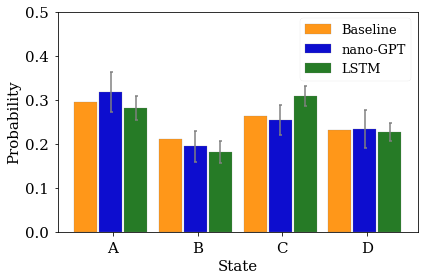

In [26]:
x =list(range(len(name_list)))
total_width, n = 0.81, 3
width = total_width / n
plt.figure(figsize=(6,4))
# plt.rcParams.update({'figure.autolayout': True})
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
for i in range(len(x)):
    x[i] = x[i] - width 
plt.bar(x, [md_count[md_count.state==i]['count'].squeeze() for i in name_list], width=width, label='Baseline',fc = 'darkorange', alpha=0.9,edgecolor = "grey")

for i in range(len(x)):
    x[i] = x[i] + width +0.025
plt.bar(x, prob_g.mean(axis=0), yerr=0.5*prob_g.std(axis=0), width=width, label='nano-GPT',tick_label = name_list,fc = 'mediumblue',alpha=0.95,
        error_kw=dict(ecolor='gray', lw=1.5, capsize=1.5, capthick=1.5), edgecolor = "grey")

for i in range(len(x)):
    x[i] = x[i] + width +0.025
plt.bar(x, prob_l.mean(axis=0), yerr=0.5*prob_l.std(axis=0), width=width, label='LSTM',tick_label = name_list,fc = 'darkgreen', alpha=0.85,
        error_kw=dict(ecolor='gray', lw=1.5, capsize=1.5, capthick=1.5), edgecolor = "grey")
plt.ylim(0,0.5)
plt.ylabel('Probability',fontsize =15)
plt.xlabel('State', fontsize =15)
# plt.ylabel('Probability',weight = 'bold')
# plt.xlabel('State',weight = 'bold')
for i in range(len(x)):
    x[i] = x[i] - width
plt.xticks(x, ['A','B','C','D'],fontsize =15)
plt.yticks(fontsize =15)
plt.legend(fontsize=13)
# plt.title("Botlzmann Distribution")
plt.savefig(f'/home/wzengad/projects/MD_code/Fig/distribution.pdf', format='pdf', dpi=600, pad_inches = 0.05)
# plt.show()

In [ ]:
x =list(range(len(name_list)))
total_width, n = 0.8, 3
width = total_width / n

for i in range(len(x)):
    x[i] = x[i] - width 
plt.bar(x, [md_count[md_count.state==i]['count'].squeeze() for i in name_list], width=width, label='Baseline',fc = '#7261ab', alpha=0.9)

for i in range(len(x)):
    x[i] = x[i] + width
plt.bar(x, prob_g.mean(axis=0), yerr=0.5*prob_g.std(axis=0), width=width, label='nano-GPT',tick_label = name_list,fc = '#f3201b',alpha=0.95,
        error_kw=dict(ecolor='gray', lw=1, capsize=2, capthick=1))

for i in range(len(x)):
    x[i] = x[i] + width
plt.bar(x, prob_l.mean(axis=0), yerr=0.5*prob_l.std(axis=0), width=width, label='LSTM',tick_label = name_list,fc = '#20b020', alpha=0.85,
        error_kw=dict(ecolor='gray', lw=1, capsize=2, capthick=1))
plt.ylim(0,0.5)
plt.ylabel('Probability',weight = 'bold')
plt.xlabel('State',weight = 'bold')
for i in range(len(x)):
    x[i] = x[i] - width
plt.xticks(x, ['A','B','C','D'])
plt.legend()
# plt.title("Botlzmann Distribution")
plt.savefig(f'/home/wzengad/projects/MD_code/Fig/distribution.pdf', format='pdf', dpi=600, pad_inches = 0.05)
plt.show()

In [ ]:

# best: sparse, epoch10
epoch = 10
gpt_path = f'/home/wzengad/projects/MD_code/LSTM/results/4state/trans_gpt/Label0.0_sparse50_interval1_lr0.0005_emb_dim128_l100_block1_scheduled/category/epoch{epoch}_120000_valid_interval1/prediction_0'
gpt = np.loadtxt(gpt_path, dtype=int).reshape(-1)

md_path = '/home/wzengad/projects/MD_code/data/4state_discrete.txt'
md = np.loadtxt(md_path, dtype=int).reshape(-1)
md = md[:int(md.shape[0]*0.8)]
md_raw = np.loadtxt('/home/wzengad/projects/MD_code/data/4state.txt').reshape(-1)

epoch=10
lstm_path = f'/home/wzengad/projects/MD_code/LSTM/results/4state/lstm/lr0.001_interval1_seq100/category/epoch{epoch}_120000_valid_interval1/prediction_0'
lstm = np.loadtxt(lstm_path, dtype=int).reshape(-1)


md_count=state_count(md)
lstm_count=state_count(lstm)
gpt_count=state_count(gpt)
 
# name_list = md_count['state'].astype(int)
name_list = [0,1,2,3]
num_list = md_count['count']
num_list1=[lstm_count[lstm_count.state==md_count['state'][i]]['count'].squeeze() for i in range(4)]
num_list2=[gpt_count[gpt_count.state==md_count['state'][i]]['count'].squeeze() for i in range(4)]

x =list(range(len(num_list)))
total_width, n = 0.8, 3
width = total_width / n
 
plt.bar(x, num_list, width=width, label='md',fc = 'dodgerblue')
for i in range(len(x)):
    x[i] = x[i] + width
plt.bar(x, num_list2, width=width, label='gpt',tick_label = name_list,fc = 'darkgreen')

for i in range(len(x)):
    x[i] = x[i] + width
plt.bar(x, num_list1, width=width, label='lstm',tick_label = name_list,fc = 'darkorange')
plt.ylim(0,0.4)
plt.legend()
plt.title("Botsman Distribution")
plt.show()

In [ ]:
from pyemma import msm, plots
def ck_test(md):
    msm_md = msm.estimate_markov_model(md, 200)
    msm_md_ck = msm_md.cktest(4)
    return msm_md
md_ck = ck_test(md).stationary_distribution
lstm_ck = ck_test(lstm).stationary_distribution
gpt_ck = ck_test(gpt).stationary_distribution

In [ ]:
import matplotlib.pyplot as plt
num_list = md_count['count']

x =list(range(len(num_list)))
total_width, n = 0.8, 3
width = total_width / n
 
plt.bar(x, md_ck, width=width, label='md',fc = 'dodgerblue')
for i in range(len(x)):
    x[i] = x[i] + width
plt.bar(x, lstm_ck, width=width, label='lstm',tick_label = name_list,fc = 'darkorange')
for i in range(len(x)):
    x[i] = x[i] + width
plt.bar(x, gpt_ck, width=width, label='md',tick_label = name_list,fc = 'darkgreen')
plt.legend()
plt.title("distribution of most populated states")
plt.show()

## free energy

In [14]:
# free energy
T = 500/60 # unit: K
beta = 1000/(T*8.28) # kT=(8.28/1000)*T (kJ/mol/K)

hist_200ns = np.histogram(md_raw, bins=40)
prob_200ns = hist_200ns[0].T/np.sum(hist_200ns[0].T)
freeE_200ns = (-1/beta) * np.log(prob_200ns-1e-11)
# freeE_200ns = -0.616 * np.log(prob_200ns-1e-11)
mids_200ns = 0.5*(hist_200ns[1][1:]+hist_200ns[1][:-1])

In [16]:
draw = pd.DataFrame({'x':mids_200ns,'md_free energy':freeE_200ns-np.min(freeE_200ns)})
draw.to_csv('/home/wzengad/projects/MD_code/Fig_data/draw/4state_freeEnergy.csv')

/home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in log
  del sys.path[0]


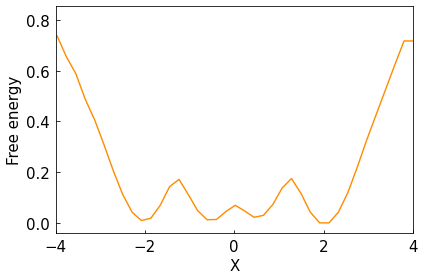

In [22]:
# free energy
T = 500/60 # unit: K
beta = 1000/(T*8.28) # kT=(8.28/1000)*T (kJ/mol/K)

hist_200ns = np.histogram(md_raw, bins=40)
prob_200ns = hist_200ns[0].T/np.sum(hist_200ns[0].T)
freeE_200ns = (-1/beta) * np.log(prob_200ns-1e-11)
# freeE_200ns = -0.616 * np.log(prob_200ns-1e-11)
mids_200ns = 0.5*(hist_200ns[1][1:]+hist_200ns[1][:-1])

hist_100ns = np.histogram(md[:20000], bins=32)
prob_100ns = hist_100ns[0].T/np.sum(hist_100ns[0].T)
freeE_100ns = (-1/beta)*np.log(prob_100ns-1e-11)
mids_100ns = 0.5*(hist_100ns[1][1:]+hist_100ns[1][:-1])

# plotting
fig, ax=plt.subplots(figsize=(6,4), nrows=1, ncols=1)
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
# ax.plot(mids_100ns, freeE_100ns-np.min(freeE_100ns), linestyle='-.', color='green', label='MD 100$ns$')
ax.plot(mids_200ns, freeE_200ns-np.min(freeE_200ns), linestyle='-', color='darkorange', label='Baseline')

ax.tick_params(axis='both', which='both', labelsize=15, direction='in')
ax.set_xlabel('X', size=15)
ax.set_ylabel('Free energy', size=15)
# ax.set_xlim(-np.pi*2, np.pi*2)
# ax.set_ylim(0, 0.8)
ax.set_xlim(-4, 4)
# ax.set_yticklabels(['0', '0.1', '0.2', '0.4','0.6'], size=15)
plt.yticks(fontsize =15)
plt.xticks(fontsize =15)
# ax.legend(loc='upper center', fontsize=20)

fig.tight_layout()
# plt.savefig('/home/wzengad/projects/MD_code/Fig/free_energy.pdf', format='pdf', dpi=600, pad_inches = 0.05)
plt.show()

In [24]:
# save md_draw, prob_l, prob_g to '/home/wzengad/projects/MD_code/Fig_data/draw/4state_distribution.csv'
for data in ['x', 'y']:
    if data == 'x':
        np.savetxt(f'/home/wzengad/projects/MD_code/Fig_data/draw/4state_free_energy_{data}.csv', mids_200ns, delimiter=',')
    elif data == 'y':
        np.savetxt(f'/home/wzengad/projects/MD_code/Fig_data/draw/4state_free_energy_{data}.csv', freeE_200ns-np.min(freeE_200ns), delimiter=',')
    

## Kinetic Distance

In [30]:
l_dis = np.loadtxt('/home/wzengad/projects/MD_code/Fig_data/draw/l_dis.txt')
g_dis = np.loadtxt('/home/wzengad/projects/MD_code/Fig_data/draw/g_dis.txt')

In [37]:
vocab_size = 4
from utils import *
def get_transition_count(md, T):
    M = [[0]*vocab_size for _ in range(vocab_size)]
    dataset = data_as_input(md, 1, T  , BUFFER_SIZE = 100000, shuffle=False, type = 'sparse')
    for item in  dataset:
        sequence = item[0].numpy()[0]
        # drop consecutive same states
        sequence = [sequence[i] for i in range(len(sequence)) if i == 0 or sequence[i] != sequence[i-1]]
        for i in range(len(sequence)-1):
            for j in range(i+1, len(sequence)):
                M[sequence[i]][sequence[j]] += 1
    return M
def NormalizeData(data):
    data = np.array(data)
    return (data - np.min(data)) / (np.max(data) - np.min(data))


In [38]:
T = 500
num_sequence = md.shape[0]//T   
M = get_transition_count(md, T)
tau = []
for i in range(4):
    for j in range(i+1,4):
        if M[i][j] != 0:
            tau.append(T/(M[i][j]/num_sequence))
        if M[j][i] != 0:
            tau.append(T/(M[j][i]/num_sequence))

assert g_dis.shape[1] == len(tau)
tau_scale = NormalizeData(tau)



In [40]:
x = np.arange(len(indice))

In [42]:
x-0.025

array([-0.025,  0.975,  1.975,  2.975,  3.975,  4.975])

/home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/ipykernel_launcher.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator


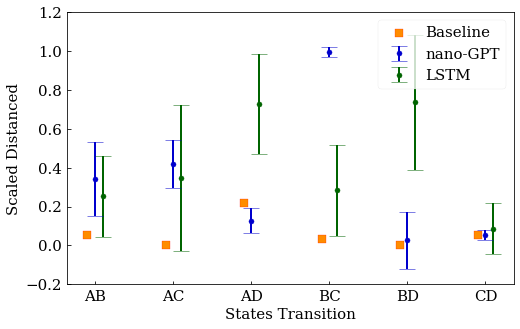

In [57]:
indice=[1,2,4,6,8,10] # keep indices and drop symmetry ones

fig, ax = plt.subplots(figsize=(8,5)) 
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
x = np.arange(len(indice))

ax.scatter(x - 0.1, tau_scale[indice], s=80, c='darkorange',marker='s', facecolor='none', edgecolor='r', label='Baseline')
# ax.scatter(np.arange(len(tau)), g_dis.mean(axis=0), s=80, facecolor='none', edgecolor='g', label='GPT')
# ax.scatter(np.arange(len(tau)), l_dis.mean(axis=0), s=80, facecolor='none', edgecolor='b', label='LSTM')
ax.errorbar(x, g_dis.mean(axis=0)[indice], c='mediumblue', yerr=g_dis.std(axis=0)[indice], fmt='o',  lw=2, markersize=5, markeredgewidth=0.5, capsize=8, label='nano-GPT')
ax.errorbar(x + 0.1, l_dis.mean(axis=0)[indice], c='darkgreen', yerr=l_dis.std(axis=0)[indice], fmt='o',  lw=2, markersize=5, markeredgewidth=0.5, capsize=8, label='LSTM')

ax.tick_params(axis='both', which='both', direction='in', labelsize=15)
ax.set_xlabel('States Transition', size=15)
ax.set_ylabel('Scaled Distanced', size=15)
ax.set_xticklabels(['','AB', 'AC', 'AD', 'BC', 'BD', 'CD'])

ax.set_ylim(-0.2, 1.2)
ax.legend(loc='upper right', fontsize=15)

# fig.tight_layout()
plt.savefig(f'/home/wzengad/projects/MD_code/Fig/kinetic_distance/Label0.0_sparse50_interval1_lr0.0005_emb_dim128_l100_block1_scheduled/T500.pdf', format='pdf', dpi=600, pad_inches = 0.05)
# print(f'kinetic_dis_ckpt{ckpt}_length{T} complete')

# RMSD dataset

In [1]:
import numpy as np
from pyemma import msm, plots
import matplotlib.pyplot as plt
import sys
import itertools
sys.path.append('/home/wzengad/projects/MD_code/LSTM')
from utils import Rm_peaks_steps

import pandas as pd
state_info = pd.read_csv('/home/wzengad/projects/MD_code/LSTM/rama_state_index.txt',sep='\s+')
def nearest_state(df, target):
    df['distance'] = (df['phi'] - target[0])**2 + (df['psi'] - target[1])**2
    state = df.sort_values(by='distance')['state']
    return state


Bad key text.latex.unicode in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 112 ('text.latex.unicode : False # use "ucs" and "inputenc" LaTeX packages for handling')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.4/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.frameon in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 423 ('savefig.frameon : True')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.4/matplotlibrc.template
or from the matplotlib source distribution

Bad key pgf.debug in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 444 ('pgf.debug           : False')
You probably need to 

In [2]:
# for lstm experiment
task = 'RMSD' 
# task = 'MacroAssignment'
datapath = f'/home/wzengad/projects/MD_code/data/{task}/train'
train=np.loadtxt(datapath, dtype=int).reshape(-1)
test = np.loadtxt(f'/home/wzengad/projects/MD_code/data/{task}/test', dtype=int).reshape(-1)




In [4]:

interval=2
lag_limit = 200 
lag_times=range(int(10/(interval*0.1)),int(lag_limit/(interval*0.1)),int(10/(interval*0.1)))

train_interval = train.reshape(-1, interval).T.flatten()
train_interval_ts = msm.its(train_interval, lag_times, nits=3, show_progress=False)


In [5]:
lr = 0.0001 if interval==2 else 0.001
pred_path = '/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval2_lr0.0005_emb_dim128_l100_block3_scheduled/category/epoch80_100000_valid_interval2'
# pred_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval{interval}_lr0.0001_emb_dim128_l100_block3_scheduled/category/epoch280_100000_valid_interval{interval}'
# pred_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval{interval}_lr{lr}_l100_block3_no_pos_scheduled/category/epoch280_100000_valid_interval{interval}'
def load_data(path):
    data = np.loadtxt(path, dtype= int)
    # data = Rm_peaks_steps(data, 100)
    return data
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]


In [ ]:
lstm_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/lstm/Label0.0_sparse50_interval{interval}_lr0.001_l100_units512_emb128_no_pos/category/epoch180_100000_valid_interval{interval}'
pred_lstm = [load_data(lstm_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]
pred_lstm = msm.its(pred_lstm, lag_times, nits=3, show_progress=False)
pred_lstm.timescales*interval

In [ ]:
lr = 0.0001 if interval==2 else 0.001
# for ITS
pred_path = '/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval2_lr0.0005_emb_dim128_l100_block1_scheduled/category/epoch280_100000_valid_interval2'
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]

# pred_traj = load_data(pred_path + f'/no_gen_pos_prediction_5')
pred_gpt = msm.its(pred_traj, lag_times, nits=3, show_progress=False)
pred_gpt.timescales*interval


In [9]:
import matplotlib.style as style 
import matplotlib
style.available

style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')

matplotlib.rcParams['font.family'] = "serif"

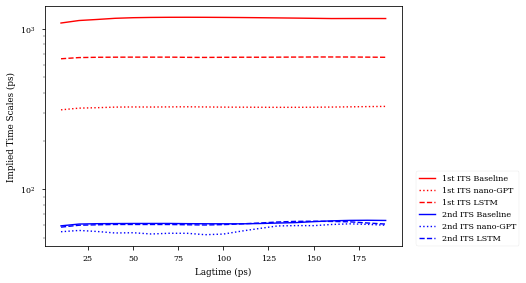

In [21]:
marker = itertools.cycle(('o', 'v', '^', '<', '>', 's', '8', 'p'))
baseline = train_interval_ts.timescales*interval*0.1
gpt = pred_gpt.timescales*interval*0.1
lstm = pred_lstm.timescales*interval*0.1
lag_times_x = np.array(lag_times)*interval*0.1

plt.plot(lag_times_x, baseline[:,0],'r', label='1st ITS Baseline')
plt.plot(lag_times_x, gpt[:,0], 'r:',label='1st ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,0], 'r--',label='1st ITS LSTM')

plt.plot(lag_times_x, baseline[:,1],'b', label='2nd ITS Baseline')
plt.plot(lag_times_x, gpt[:,1], 'b:',label='2nd ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,1], 'b--',label='2nd ITS LSTM')

# plt.plot(lag_times_x, baseline[:,2],'g', label='3rd ITS Baseline')
# plt.plot(lag_times_x, gpt[:,2], 'g:',label='3rd ITS nano-GPT')
# plt.plot(lag_times_x, lstm[:,2], 'g--',label='3rd ITS LSTM')

plt.legend(loc=(1.04, 0))
plt.ylabel('Implied Time Scales (ps)')
plt.yscale("log")
plt.xlabel('Lagtime (ps)')
plt.show()
# plt.savefig(f'/home/wzengad/projects/MD_code/Fig/ITS_{interval}.pdf', format='pdf',bbox_inches='tight', dpi=600, pad_inches = 0.05)

In [ ]:
transition = ['AB','BA','AC','CA','AD','DA','BC','CB','BD','DB','CD','DC']
plots = [4,5,6,7]
import matplotlib.style as style 
import matplotlib
style.available
style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')
# style.use('_mpl-gallery')
matplotlib.rcParams['font.family'] = "serif"

for plot_choice in plots:
 

    g_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/g_plot',dtype=int)
    l_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/l_plot',dtype=int)
    M_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/m_plot',dtype=int)

    fig, ax = plt.subplots(figsize=(12,4)) 
    ax.scatter(np.arange(len(M_plot)), M_plot, s=80, marker='s', facecolor='none', edgecolor='r', c='darkorange', label= 'Baseline')
    ax.errorbar(np.arange(len(M_plot)), g_plot.mean(axis=0), yerr=g_plot.std(axis=0), fmt='o', c='mediumblue',  markersize=5, capsize=10, label='nano-GPT')
    ax.errorbar(np.arange(len(M_plot)), l_plot.mean(axis=0), yerr=l_plot.std(axis=0), fmt='o',   c='darkgreen', markersize=5, capsize=10, label='LSTM')

    ax.tick_params(axis='both', which='both', direction='in', labelsize=16)
    ax.set_xlabel('Commit Time', size=16)
    ax.set_ylabel('Count', size=16)
    # x=np.arange(len(M_plot))
    # x = [0,5,10,15,20,25]
    # ax.set_xticks(x, [str(i*50) for i in x])
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    # ax.set_xtickslabels([str(i*50) for i in x])
    # ax.set_ylim(-0.2, 30)
    ax.legend(loc='center right', fontsize=16)

    fig.tight_layout()
    plt.savefig(f'/home/wzengad/projects/MD_code/Fig/adjacent_count/{transition[plot_choice]}.pdf', format='pdf', dpi=600, pad_inches = 0.05)


In [2]:
alpha_l = (50, 30)
alpha_r = (-70, -20)
beta = (-130,170)
c5 = (-90, 170)
c7eq = (-80,70)
c7ax = (70,-50)

alpha_l_state = nearest_state(state_info, alpha_l).iloc[0]
alpha_r_state = nearest_state(state_info, alpha_r).iloc[0]
beta_state = nearest_state(state_info, beta).iloc[0]
c5_state= nearest_state(state_info, c5).iloc[0]
c7eq_state = nearest_state(state_info, c7eq).iloc[0]
c7ax_state = nearest_state(state_info, c7ax).iloc[0]

In [17]:
from pyemma import msm
# msm_nrev = msm.estimate_markov_model(train, 100)
msm_nrev_pred = msm.estimate_markov_model(pred_traj, int(100/interval))

print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')
print(f'c7eq to c7ax: generated trajectory: {msm_nrev_pred.mfpt(c7eq_state,c7ax_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c7ax_state,c7eq_state)*interval}')

alpha_l to alpha_r: generated trajectory: 6550.479541551819
reverse: generated trajectory: 2177728.613881255
alpha_l to beta: generated trajectory: 5664.273200281519
reverse: generated trajectory: 2177240.789958218
alpha_l to c5: generated trajectory: 53039.017848462856
reverse: generated trajectory: 2177241.1653784337
c7eq to c7ax: generated trajectory: 20606339.670579117
reverse: generated trajectory: 2396997.664374302


In [29]:
from pyemma import msm
msm_nrev = msm.estimate_markov_model(train, 100)
msm_nrev_pred = msm.estimate_markov_model(pred_traj, int(100/interval))

In [30]:

print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to alpha_r: generated trajectory: 4622985.153398817
reverse: generated trajectory: 4809839.513611699
alpha_l to beta: generated trajectory: 3521.5768987015786
reverse: generated trajectory: 4809803.331729418
alpha_l to c5: generated trajectory: 50655.54297866125
reverse: generated trajectory: 4809803.8697033385


In [93]:

# msm_nrev = msm.estimate_markov_model(train_interval, 100)
# for train dataset
print(f'alpha_l to alpha_r: LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse:LSTM trajectory: {msm_nrev.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta:  LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse:  LSTM trajectory: {msm_nrev.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: LSTM trajectory: {msm_nrev.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to alpha_r: LSTM trajectory: 17123.419557988298
reverse:LSTM trajectory: 1271784.9443395415
alpha_l to beta:  LSTM trajectory: 15246.837458311145
reverse:  LSTM trajectory: 1270875.6476046958
alpha_l to c5: LSTM trajectory: 97598.02766841787
reverse: LSTM trajectory: 1270780.4723086588


In [87]:
# for i in range(1,4):
#     for j in range(i):
i=1
j=2
print(f'{i} to {j}: MD trajectory: {msm_nrev.mfpt(i,j)} , LSTM trajectory: {msm_nrev_pred.mfpt(i,j)*interval}')
print(f'{j} to {i}: MD trajectory: {msm_nrev.mfpt(j,i)} , LSTM trajectory: {msm_nrev_pred.mfpt(j,i)*interval}')

1 to 2: MD trajectory: 13957.31609237181 , LSTM trajectory: 11414.883473743414
2 to 1: MD trajectory: 462855.48167126183 , LSTM trajectory: 582110.8834685114


In [5]:
alpha_l = (50, 30)
alpha_r = (-70, -20)
beta = (-130,170)
c5 = (-90, 170)

alpha_l_state = nearest_state(state_info, alpha_l).iloc[0]
alpha_r_state = nearest_state(state_info, alpha_r).iloc[0]
beta_state = nearest_state(state_info, beta).iloc[0]
c5_state= nearest_state(state_info, c5).iloc[0]

In [51]:
print(f'alpha_l to alpha_r: MD trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(alpha_r_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')

alpha_l to alpha_r: MD trajectory: 15043.866527972968 , LSTM trajectory: 11107.84914390189
reverse: MD trajectory: 849212.3192883419 , LSTM trajectory: 701385.6619736312


In [52]:
print(f'alpha_l to beta: MD trajectory: {msm_nrev.mfpt(alpha_l_state,beta_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(beta_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')

alpha_l to beta: MD trajectory: 13020.888900678447 , LSTM trajectory: 9121.03058146158
reverse: MD trajectory: 848360.5260336131 , LSTM trajectory: 701019.284133374


In [53]:
print(f'alpha_l to c5: MD trajectory: {msm_nrev.mfpt(alpha_l_state,c5_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(c5_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to c5: MD trajectory: 54174.45137544599 , LSTM trajectory: 47925.21093674335
reverse: MD trajectory: 848299.1275348164 , LSTM trajectory: 700887.2641091458


In [19]:
c7ax_state

81

In [ ]:
c7eq=15
c7ax = [7,53,81]
# this is mfpt for md trajectory
for i in c7ax:
    print(f'c7eq to c7ax({i}): MD trajectory: {msm.tpt(msm_nrev, [c7eq], [i])} , LSTM trajectory: {msm.tpt(msm_nrev_pred, [c7eq], [i])}')
 

In [ ]:
# lagtimes=[100,200,300,400,500,600,700,800,900,1000]
lagtimes=list(range(10,200,10))
mfpts=[]
for lagtime in lagtimes:
    # msm_nrev = msm.estimate_markov_model(train, lagtime, reversible=True)
    msm_nrev = msm.estimate_markov_model(train, lagtime, reversible=False)
    mfpts.append(msm.tpt(msm_nrev, [beta_state], [alpha_l_state]).mfpt)

x = [0]+lagtimes
y = [0]+mfpts

In [ ]:
plt.plot(x,y)

In [ ]:
c7eq=15
c7ax = [7,53,81]
# this is mfpt for md trajectory
for i in c7ax:
    print(f'c7eq to c7ax({i}): MD trajectory: {msm_nrev.mfpt(c7eq,i)} , LSTM trajectory: {msm_nrev_pred.mfpt(c7eq,i)}')
    # print(f'c7ax({i}) to c7eq: md trajectory: {msm_nrev.mfpt(i, c7eq)} , lstm trajectory: {msm_nrev_pred.mfpt(i, c7eq)}')

In [ ]:
mm = msm.estimate_markov_model(pred_traj, 100)
mm_ck = mm.cktest(4)
len(mm.stationary_distribution)
# mm_ck.estimates.shape
# diagnoal element in ck_test: mm_ck.estimates[:,1,1]
# plots.plot_cktest(mm_ck, diag=True)

In [ ]:
mm_t = msm.estimate_markov_model(train, 200)
mm_ck_t = mm.cktest(4)
# plots.plot_cktest(mm_ck_t, diag=True)

In [ ]:
# Propagates the initial distribution p0 k times
initial = np.zeros(100)
initial[0] = 1
mm_t.propagate(initial,4)

In [ ]:
import matplotlib.pyplot as plt
x = range(len(mm_t.stationary_distribution))

plt.title("stationary distribution for states")
plt.xlabel("state")
# plt.xticks(x,[i for i in data.index])
plt.ylabel("stationary distribution")
plt.plot(x, mm.stationary_distribution,'-',label="groundtruth")
plt.plot(x, mm_t.stationary_distribution,'-',color='r',label="lstm prediction")
plt.legend()


In [ ]:
# this is mfpt for lstm trajectory
msm_nrev_pred.mfpt(15,7)

In [ ]:
mfpt = np.zeros((nstates, nstates))
for i in range(nstates):
    for j in range(nstates):
        mfpt[i, j] = msm_nrev.mfpt(i,j)

In [ ]:
hmm_tx = msm.timescales_hmsm(pred_traj, 2, lags=lag_times, errors='bayes', show_progress=False)

# simulation dataset

In [ ]:
# for simulation dataset
lag_times=range(1,40,1)

traj = np.loadtxt('/home/wzengad/projects/MD_code/LSTM/results/4state_lr0.001_interval1_seq100/prediction_0', dtype=int)
ts = msm.its(traj, lag_times, show_progress=False)

real_traj = np.loadtxt('/home/wzengad/projects/MD_code/data/4state_discrete.txt', dtype=int)
real_ts = msm.its(real_traj, lag_times, show_progress=False)

nc_traj = np.loadtxt('/home/wzengad/projects/LSTM-predict-MD/prediction_tiwary')
nc_traj = nc_traj.astype('int')
nc_ts = msm.its(nc_traj, lag_times, show_progress=False)



In [ ]:
plt.plot(lag_times, ts.timescales)

In [ ]:
plt.plot(lag_times, real_ts.timescales)

In [ ]:
plt.plot(lag_times, nc_ts.timescales)

In [ ]:
# evaluate on HMM
mm = msm.estimate_hidden_markov_model(traj, 4, 4)
# evaluate on MM
msm = msm.estimate_markov_model(traj, lag=1)
# mfpt between state0 and state1
# mm.mfpt(0, 1)

In [ ]:
mm_ck = mm.cktest()
plots.plot_cktest(mm_ck, diag=True)